In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [3]:
import os

dataset_path = "/kaggle/input/140k-real-and-fake-faces"

# Walk through the directory
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}[DIR] {os.path.basename(root)}")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:  # print only the first 5 files per folder
        print(f"{subindent}{f}")


[DIR] 140k-real-and-fake-faces
    valid.csv
    train.csv
    test.csv
    [DIR] real_vs_fake
        [DIR] real-vs-fake
            [DIR] valid
                [DIR] fake
                    W3DVWMWYOI.jpg
                    IQEOWSOAID.jpg
                    8JL4TYOH6D.jpg
                    69FFH5KFY8.jpg
                    ZZAA0631IK.jpg
                [DIR] real
                    16916.jpg
                    06122.jpg
                    08536.jpg
                    59735.jpg
                    13288.jpg
            [DIR] test
                [DIR] fake
                    DAOH5G9O0Z.jpg
                    IPZTUVD9OS.jpg
                    8L0KA3MXPC.jpg
                    UU38CFFH24.jpg
                    G88GNSJ3YI.jpg
                [DIR] real
                    52876.jpg
                    59454.jpg
                    53932.jpg
                    52203.jpg
                    28578.jpg
            [DIR] train
                [DIR] fake
                    H7

Count Total Images & Per Class



In [4]:
import os

# Paths
base_path = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
splits = ["train", "valid", "test"]
classes = ["real", "fake"]

image_stats = {}

for split in splits:
    image_stats[split] = {}
    for cls in classes:
        folder_path = os.path.join(base_path, split, cls)
        image_count = len(os.listdir(folder_path))
        image_stats[split][cls] = image_count

# Display
for split in image_stats:
    total = sum(image_stats[split].values())
    print(f"\n📂 {split.upper()} SET")
    print(f"  ➤ Total images: {total}")
    for cls in classes:
        print(f"  - {cls.title():<5}: {image_stats[split][cls]} images")



📂 TRAIN SET
  ➤ Total images: 100000
  - Real : 50000 images
  - Fake : 50000 images

📂 VALID SET
  ➤ Total images: 20000
  - Real : 10000 images
  - Fake : 10000 images

📂 TEST SET
  ➤ Total images: 20000
  - Real : 10000 images
  - Fake : 10000 images


Check Image Formats & Naming Patterns

In [5]:
from collections import Counter

formats = []
sample_names = []

for cls in classes:
    folder = os.path.join(base_path, "train", cls)
    files = os.listdir(folder)
    formats += [os.path.splitext(f)[1].lower() for f in files]
    sample_names += files[:5]

# Count formats
format_counts = Counter(formats)
print("\n🖼️ Image formats used:")
for fmt, count in format_counts.items():
    print(f"  {fmt}: {count} images")

# Show sample names
print("\n🔠 Sample filenames:")
for name in sample_names:
    print(" ", name)



🖼️ Image formats used:
  .jpg: 100000 images

🔠 Sample filenames:
  64601.jpg
  31973.jpg
  30778.jpg
  08450.jpg
  19812.jpg
  H7PRNYG8IN.jpg
  DDOZKDIOZD.jpg
  17V8M9SOGJ.jpg
  Z387I5ORZQ.jpg
  ZLXX27PPWK.jpg


Check Image Dimensions


In [6]:
from PIL import Image
from collections import Counter
import os

# Sample directory (train/real)
sample_dir = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real"

# Collect dimensions
dimensions = []

for file in os.listdir(sample_dir)[:1000]:  # Adjust number for speed/performance
    path = os.path.join(sample_dir, file)
    try:
        img = Image.open(path)
        dimensions.append(img.size)  # (width, height)
        img.close()
    except Exception as e:
        print(f"Error with {file}: {e}")

# Count dimensions
dim_counts = Counter(dimensions)
most_common_dim = dim_counts.most_common(1)[0]

print("📏 Image Dimensions")
print(f"  Unique sizes: {len(dim_counts)}")
print(f"  Most common: {most_common_dim[0]} ({most_common_dim[1]} images)")


📏 Image Dimensions
  Unique sizes: 1
  Most common: (256, 256) (1000 images)


Check Color Channels

In [7]:
color_modes = []

for file in os.listdir(sample_dir)[:1000]:
    path = os.path.join(sample_dir, file)
    try:
        img = Image.open(path)
        color_modes.append(img.mode)  # RGB, L, RGBA, etc.
        img.close()
    except Exception as e:
        print(f"Error with {file}: {e}")

# Count color modes
mode_counts = Counter(color_modes)

print("\n🎨 Color Modes")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count} images")



🎨 Color Modes
  RGB: 1000 images


Check File Sizes

In [8]:
import numpy as np

file_sizes = []

for file in os.listdir(sample_dir)[:1000]:
    path = os.path.join(sample_dir, file)
    try:
        size = os.path.getsize(path)
        file_sizes.append(size)
    except Exception as e:
        print(f"Error with {file}: {e}")

# File size stats
print("\n💾 File Sizes (in bytes)")
print(f"  Min size: {np.min(file_sizes)}")
print(f"  Max size: {np.max(file_sizes)}")
print(f"  Mean size: {np.mean(file_sizes):.2f}")
print(f"  Std Dev: {np.std(file_sizes):.2f}")



💾 File Sizes (in bytes)
  Min size: 19294
  Max size: 43225
  Mean size: 28914.61
  Std Dev: 4113.48


Visual Inspection of Samples


🖼️ Displaying sample images from all splits...


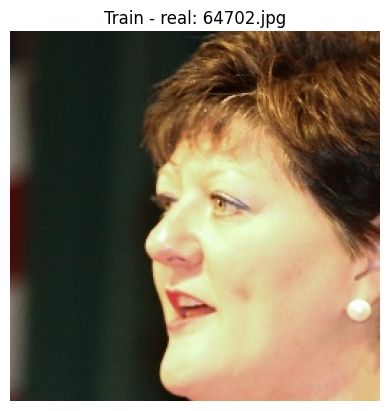

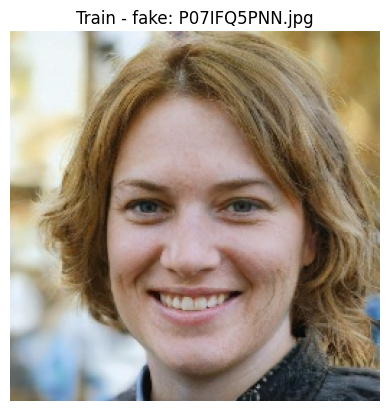

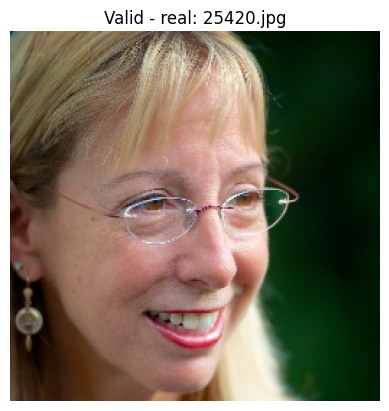

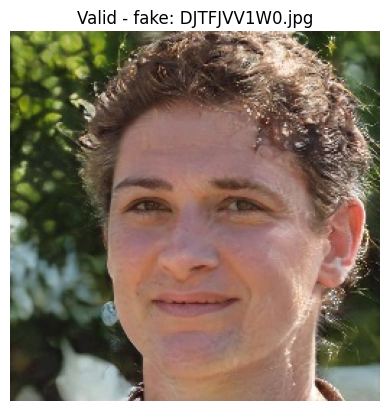

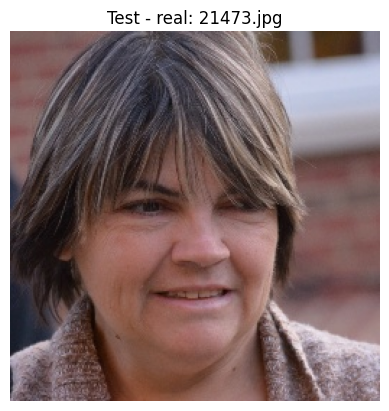

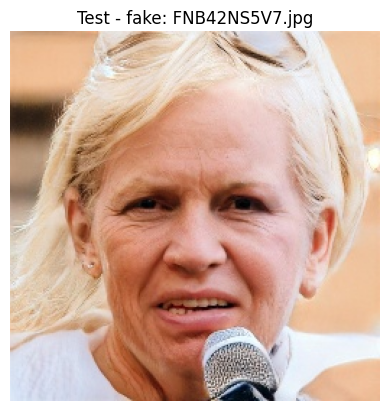

In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Directories for real and fake images in all splits
directories = {
    'train': {
        'real': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real",
        'fake': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/fake"
    },
    'valid': {
        'real': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/real",
        'fake': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/fake"
    },
    'test': {
        'real': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/real",
        'fake': "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake"
    }
}

# Function to display a random image from any directory
def show_random_image(split, label):
    image_file = random.choice(os.listdir(directories[split][label]))
    image_path = os.path.join(directories[split][label], image_file)
    try:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(f"{split.capitalize()} - {label}: {image_file}")
        plt.axis('off')  # Hide axis
        plt.show()
    except Exception as e:
        print(f"Error displaying image {image_file}: {e}")

# Display one image from each part of the dataset (train, valid, test)
print("🖼️ Displaying sample images from all splits...")

for split in directories:
    show_random_image(split, 'real')
    show_random_image(split, 'fake')


Examine Image Quality & Variations

Check Brightness/Contrast

In [10]:
import numpy as np
from PIL import ImageEnhance

# Function to check image brightness
def check_brightness(image_path):
    try:
        img = Image.open(image_path)
        # Convert to grayscale to analyze brightness
        grayscale_img = img.convert('L')
        np_img = np.array(grayscale_img)
        avg_brightness = np.mean(np_img)  # Average pixel intensity
        return avg_brightness
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Check random images for brightness
print("🌞 Brightness Check for Random Images")

for split in directories:
    for label in ['real', 'fake']:
        image_file = random.choice(os.listdir(directories[split][label]))
        image_path = os.path.join(directories[split][label], image_file)
        brightness = check_brightness(image_path)
        if brightness is not None:
            print(f"{split.capitalize()} - {label}: {image_file} | Avg Brightness: {brightness:.2f}")


🌞 Brightness Check for Random Images
Train - real: 46112.jpg | Avg Brightness: 96.86
Train - fake: BW8WMGI3SL.jpg | Avg Brightness: 79.12
Valid - real: 24660.jpg | Avg Brightness: 126.96
Valid - fake: 16QSCLVYE4.jpg | Avg Brightness: 165.17
Test - real: 53523.jpg | Avg Brightness: 116.26
Test - fake: EFWH737M75.jpg | Avg Brightness: 113.52


Detect Noise/Artifacts

In [11]:
from PIL import ImageFilter

# Function to check image sharpness
def check_sharpness(image_path):
    try:
        img = Image.open(image_path)
        sharpness = img.filter(ImageFilter.FIND_EDGES)  # Sharpness filter
        sharpness = np.array(sharpness)
        avg_sharpness = np.mean(sharpness)
        return avg_sharpness
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Check random images for sharpness
print("\n⚡ Sharpness Check for Random Images")

for split in directories:
    for label in ['real', 'fake']:
        image_file = random.choice(os.listdir(directories[split][label]))
        image_path = os.path.join(directories[split][label], image_file)
        sharpness = check_sharpness(image_path)
        if sharpness is not None:
            print(f"{split.capitalize()} - {label}: {image_file} | Avg Sharpness: {sharpness:.2f}")



⚡ Sharpness Check for Random Images
Train - real: 65581.jpg | Avg Sharpness: 17.91
Train - fake: 1KKVG36O4U.jpg | Avg Sharpness: 25.77
Valid - real: 26570.jpg | Avg Sharpness: 16.66
Valid - fake: QIDDL3N15C.jpg | Avg Sharpness: 22.25
Test - real: 68272.jpg | Avg Sharpness: 17.77
Test - fake: XJHD3AI66P.jpg | Avg Sharpness: 16.72


Detect Occlusions/Obstructions

In [12]:
# Function to check occlusions by looking for large areas of solid color
def check_occlusions(image_path, threshold=0.95):
    try:
        img = Image.open(image_path)
        np_img = np.array(img)
        # Check for percentage of pixels that are solid color (assuming background is white or black)
        non_bg_pixels = np.sum(np_img > 240)  # Adjust if background is black or other color
        total_pixels = np_img.size
        occlusion_ratio = non_bg_pixels / total_pixels
        return occlusion_ratio
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Check random images for occlusions
print("\n🚧 Occlusion Check for Random Images")

for split in directories:
    for label in ['real', 'fake']:
        image_file = random.choice(os.listdir(directories[split][label]))
        image_path = os.path.join(directories[split][label], image_file)
        occlusion = check_occlusions(image_path)
        if occlusion is not None:
            print(f"{split.capitalize()} - {label}: {image_file} | Occlusion Ratio: {occlusion:.2f}")



🚧 Occlusion Check for Random Images
Train - real: 02596.jpg | Occlusion Ratio: 0.11
Train - fake: MM9RE1ITZ8.jpg | Occlusion Ratio: 0.09
Valid - real: 55012.jpg | Occlusion Ratio: 0.01
Valid - fake: 29U8LI525K.jpg | Occlusion Ratio: 0.00
Test - real: 05304.jpg | Occlusion Ratio: 0.00
Test - fake: PHRN8WRXKK.jpg | Occlusion Ratio: 0.00


In [13]:
from skimage.measure import shannon_entropy

# Function to calculate image entropy
def check_entropy(image_path):
    try:
        img = Image.open(image_path)
        np_img = np.array(img.convert('L'))  # Convert to grayscale for entropy calculation
        entropy = shannon_entropy(np_img)
        return entropy
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Check random images for background clutter (high entropy)
print("\n🌪️ Background Clutter (Entropy) Check for Random Images")

for split in directories:
    for label in ['real', 'fake']:
        image_file = random.choice(os.listdir(directories[split][label]))
        image_path = os.path.join(directories[split][label], image_file)
        entropy = check_entropy(image_path)
        if entropy is not None:
            print(f"{split.capitalize()} - {label}: {image_file} | Entropy: {entropy:.2f}")




🌪️ Background Clutter (Entropy) Check for Random Images
Train - real: 32226.jpg | Entropy: 7.21
Train - fake: 7HTIMGDS03.jpg | Entropy: 7.59
Valid - real: 31790.jpg | Entropy: 7.26
Valid - fake: NRTH92VM2O.jpg | Entropy: 7.41
Test - real: 40923.jpg | Entropy: 7.28
Test - fake: 9OLF4YP6B3.jpg | Entropy: 7.47


Check for Bias and Diversity

Representation Bias

In [14]:
import os

def count_images_by_class(base_dir):
    splits = ['train', 'valid', 'test']
    classes = ['real', 'fake']
    result = {}

    for split in splits:
        result[split] = {}
        for cls in classes:
            folder = os.path.join(base_dir, split, cls)
            count = len(os.listdir(folder))
            result[split][cls] = count

    return result

base_path = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
class_counts = count_images_by_class(base_path)

for split, counts in class_counts.items():
    print(f"\n📁 {split.capitalize()}")
    for label, count in counts.items():
        print(f"  - {label.capitalize()} images: {count}")



📁 Train
  - Real images: 50000
  - Fake images: 50000

📁 Valid
  - Real images: 10000
  - Fake images: 10000

📁 Test
  - Real images: 10000
  - Fake images: 10000


Perspective/Viewpoint Bias

<ipython-input-15-f0e6ed852c76>:15: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


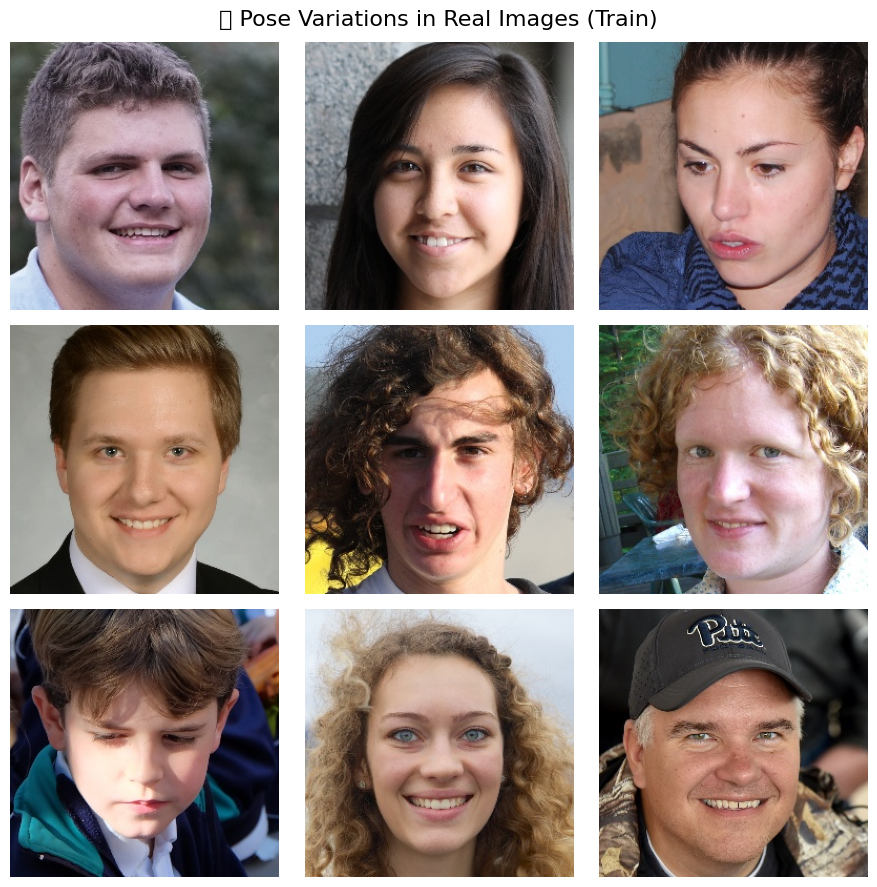

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_view_angles(image_dir, title):
    image_paths = random.sample(os.listdir(image_dir), 9)
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    fig.suptitle(title, fontsize=16)

    for ax, image_name in zip(axes.flat, image_paths):
        img = Image.open(os.path.join(image_dir, image_name))
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize pose diversity
real_train_dir = os.path.join(base_path, "train", "real")
show_view_angles(real_train_dir, "👀 Pose Variations in Real Images (Train)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.0 MB/s eta 0:00:00


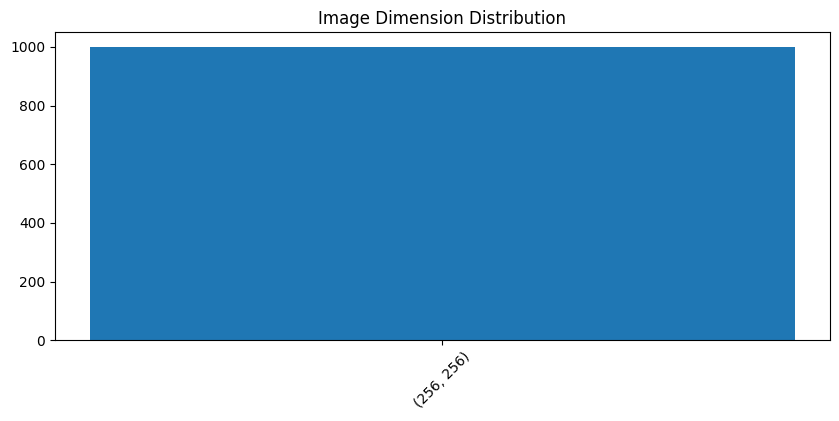

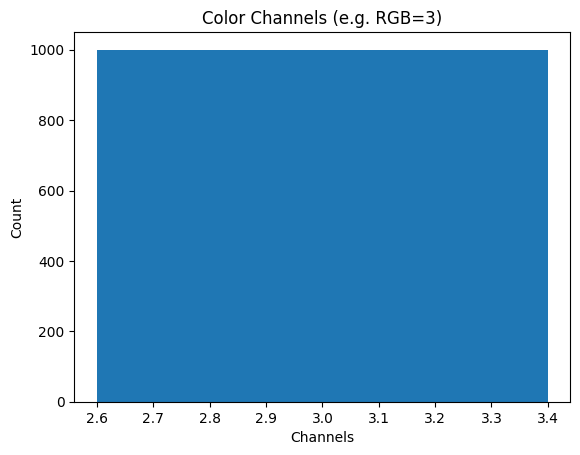

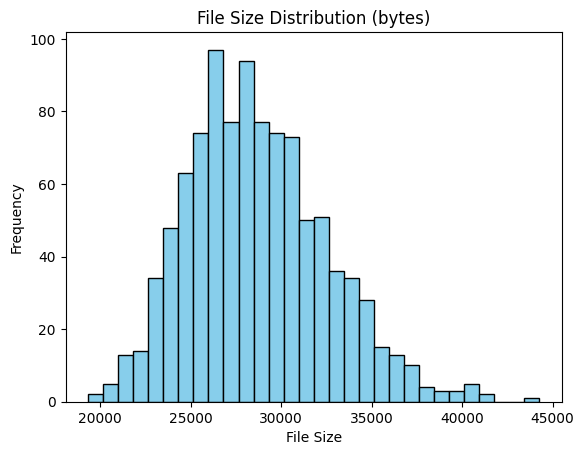

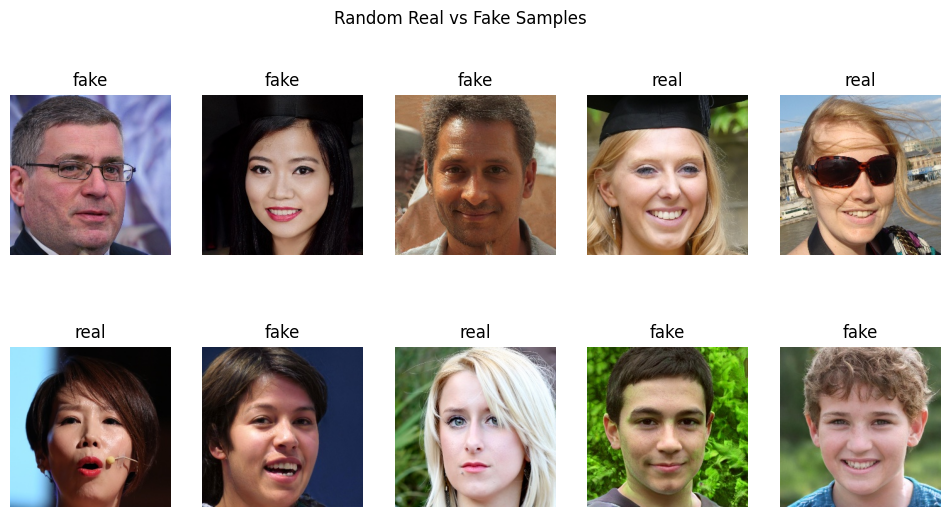

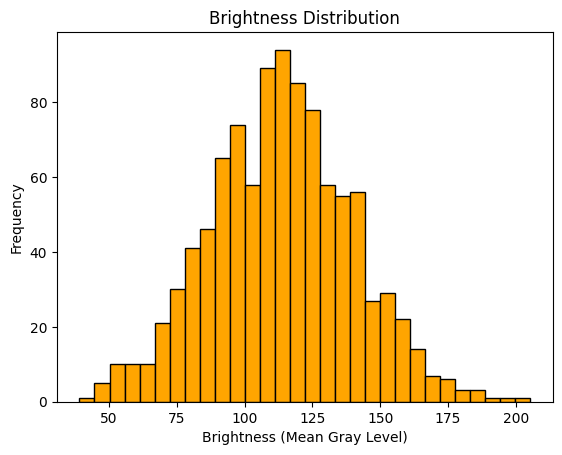

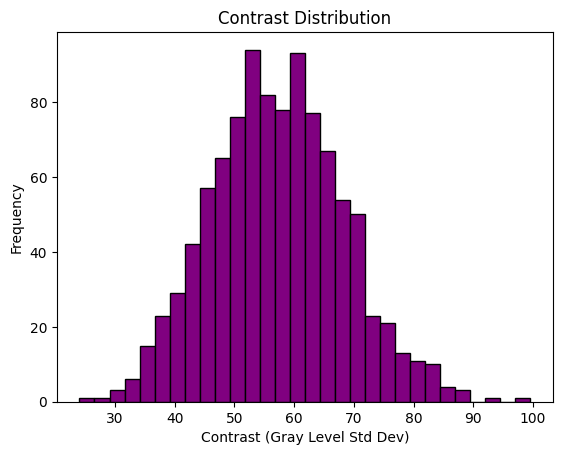

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


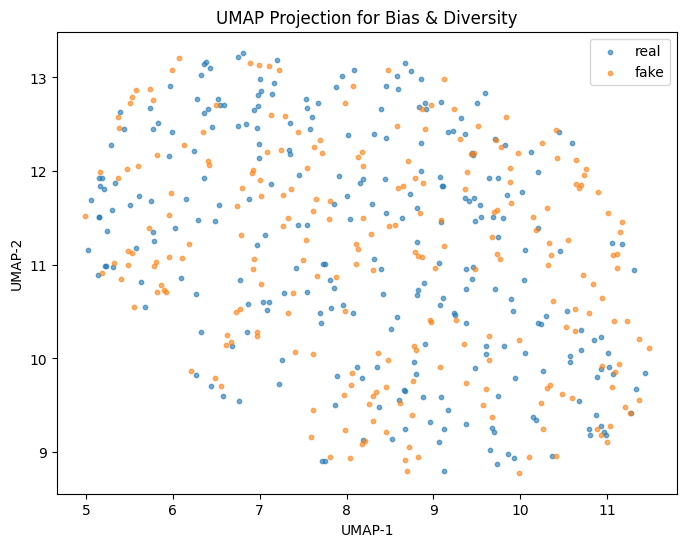

In [16]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from collections import Counter

# Optional: for bias & diversity analysis
!pip install umap-learn --quiet
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Folder paths (update if different)
root_dir = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/"
splits = ["train", "valid", "test"]

# Collect image paths
image_paths = []
for split in splits:
    for cls in ['real', 'fake']:
        paths = glob(os.path.join(root_dir, split, cls, "*.jpg"))
        image_paths.extend([(p, cls) for p in paths])

# Shuffle and sample
sample_size = 1000
sample_images = random.sample(image_paths, min(sample_size, len(image_paths)))

# -------- Step 2: Analyze Image Metadata -------- #
dimensions = []
channels = []
file_sizes = []

for path, _ in sample_images:
    img = Image.open(path)
    dimensions.append(img.size)
    channels.append(len(img.getbands()))
    file_sizes.append(os.path.getsize(path))

# Plot: Image dimensions
dim_counter = Counter(dimensions)
plt.figure(figsize=(10, 4))
plt.bar([str(k) for k in dim_counter.keys()], dim_counter.values())
plt.title("Image Dimension Distribution")
plt.xticks(rotation=45)
plt.show()

# Plot: Channels
channel_counter = Counter(channels)
plt.bar(channel_counter.keys(), channel_counter.values())
plt.title("Color Channels (e.g. RGB=3)")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.show()

# Plot: File sizes
plt.hist(file_sizes, bins=30, color='skyblue', edgecolor='black')
plt.title("File Size Distribution (bytes)")
plt.xlabel("File Size")
plt.ylabel("Frequency")
plt.show()

# -------- Step 3: Visual Inspection of Samples -------- #
def plot_samples(images, title):
    plt.figure(figsize=(12, 6))
    for i in range(10):
        path, label = random.choice(images)
        img = Image.open(path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(label)
    plt.suptitle(title)
    plt.show()

plot_samples(sample_images, "Random Real vs Fake Samples")

# -------- Step 4: Brightness & Contrast -------- #
brightness = []
contrast = []

for path, _ in sample_images:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(np.mean(gray))
    contrast.append(np.std(gray))

# Plot brightness
plt.hist(brightness, bins=30, color='orange', edgecolor='black')
plt.title("Brightness Distribution")
plt.xlabel("Brightness (Mean Gray Level)")
plt.ylabel("Frequency")
plt.show()

# Plot contrast
plt.hist(contrast, bins=30, color='purple', edgecolor='black')
plt.title("Contrast Distribution")
plt.xlabel("Contrast (Gray Level Std Dev)")
plt.ylabel("Frequency")
plt.show()

# -------- Step 5: Bias & Diversity using UMAP (Optional) -------- #
# Flatten image features (downsample first)
image_vectors = []
labels = []

for path, label in sample_images[:500]:  # fewer samples for speed
    img = cv2.imread(path)
    img = cv2.resize(img, (64, 64))  # downsample
    img = img.astype(np.float32) / 255.0
    image_vectors.append(img.flatten())
    labels.append(label)

scaler = StandardScaler()
scaled_vecs = scaler.fit_transform(image_vectors)
reducer = umap.UMAP()
embedding = reducer.fit_transform(scaled_vecs)

# Plot embeddings
plt.figure(figsize=(8, 6))
for cls in ['real', 'fake']:
    idxs = [i for i, l in enumerate(labels) if l == cls]
    plt.scatter(embedding[idxs, 0], embedding[idxs, 1], label=cls, alpha=0.6, s=10)
plt.legend()
plt.title("UMAP Projection for Bias & Diversity")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()
